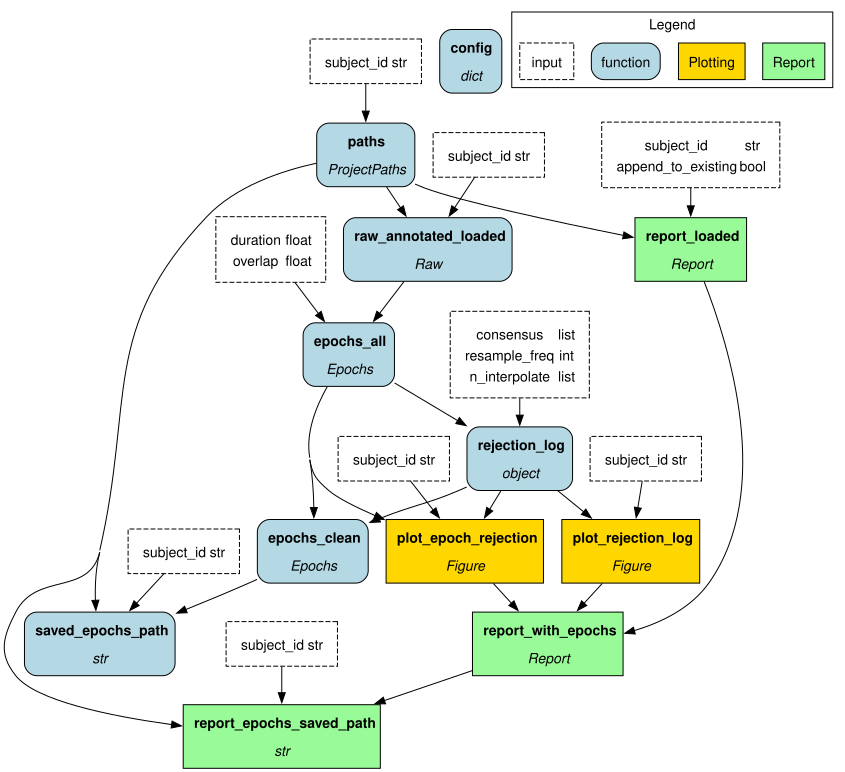

In [1]:
from IPython.display import display
from hamilton import telemetry

telemetry.disable_telemetry()

from hamilton import driver
from spectral.flows import epoching, ica_flow 
from spectral.helpers import style_cfg

# Initialize Driver
dr = driver.Driver({}, epoching)

# 2. Display
dr.display_all_functions(orient="TB", custom_style_function=style_cfg)

In [2]:
results = dr.execute(
    final_vars=["plot_epoch_rejection", "report_epochs_saved_path","saved_epochs_path"],
    inputs={
        "subject_id": "170",
        "append_to_existing": False
    },
)

Created directories for sub-170
Project root: /Users/daniel/PhD/Projects/psd-paths
Opening raw data file /Users/daniel/PhD/Projects/psd-paths/data/derrivatives/sub-170/preprocessed/sub-170_annotated_filtered_raw.fif...
    Range : 0 ... 78719 =      0.000 ...   314.876 secs
Ready.
Reading 0 ... 78719  =      0.000 ...   314.876 secs...
Not setting metadata
208 matching events found
No baseline correction applied
0 projection items activated
Using data from preloaded Raw for 208 events and 751 original time points ...
2 bad epochs dropped
fitting finished
Dropped 2 epochs: 192, 193
    Using multitaper spectrum estimation with 7 DPSS windows
Plotting power spectral density (dB=True).
Averaging across epochs before plotting...
    Using multitaper spectrum estimation with 7 DPSS windows
Plotting power spectral density (dB=True).
Averaging across epochs before plotting...
Creating new report from scratch for subject 170

Problematic epochs (< 75% good channels) for subject 170:
  Epoch 16

It appears no Pandas index type was detected (ignore this warning if you're using DASK for now.) Please check whether the dataframe created matches what what you expect to happen.


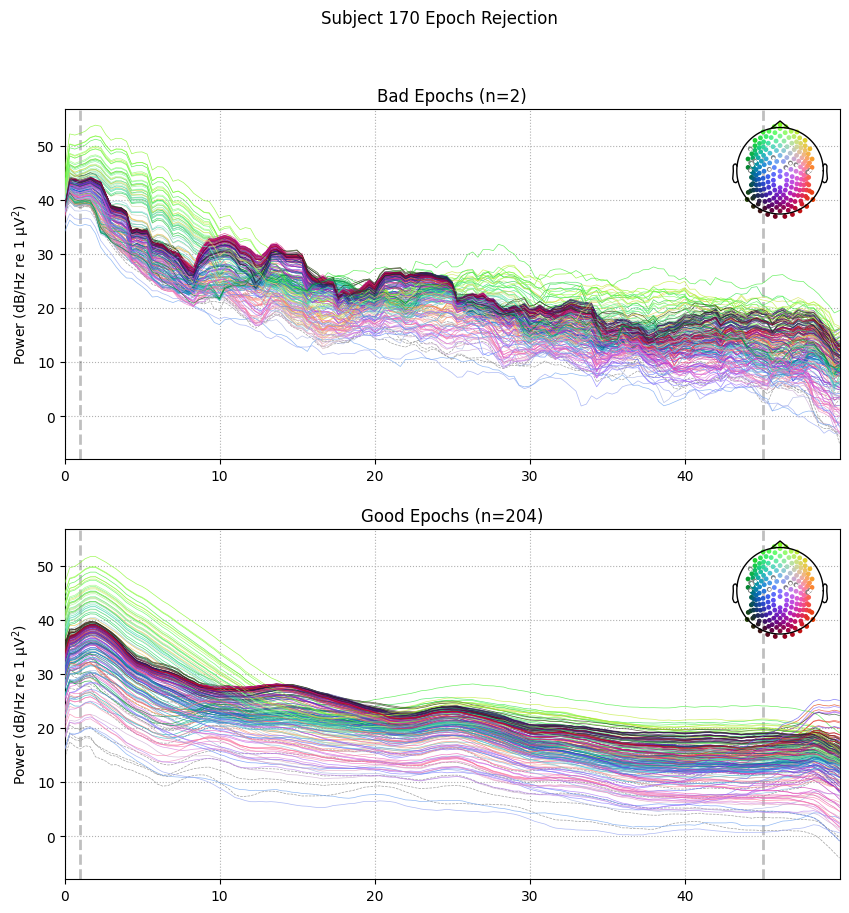

In [3]:
display(results["plot_epoch_rejection"].iloc[0])

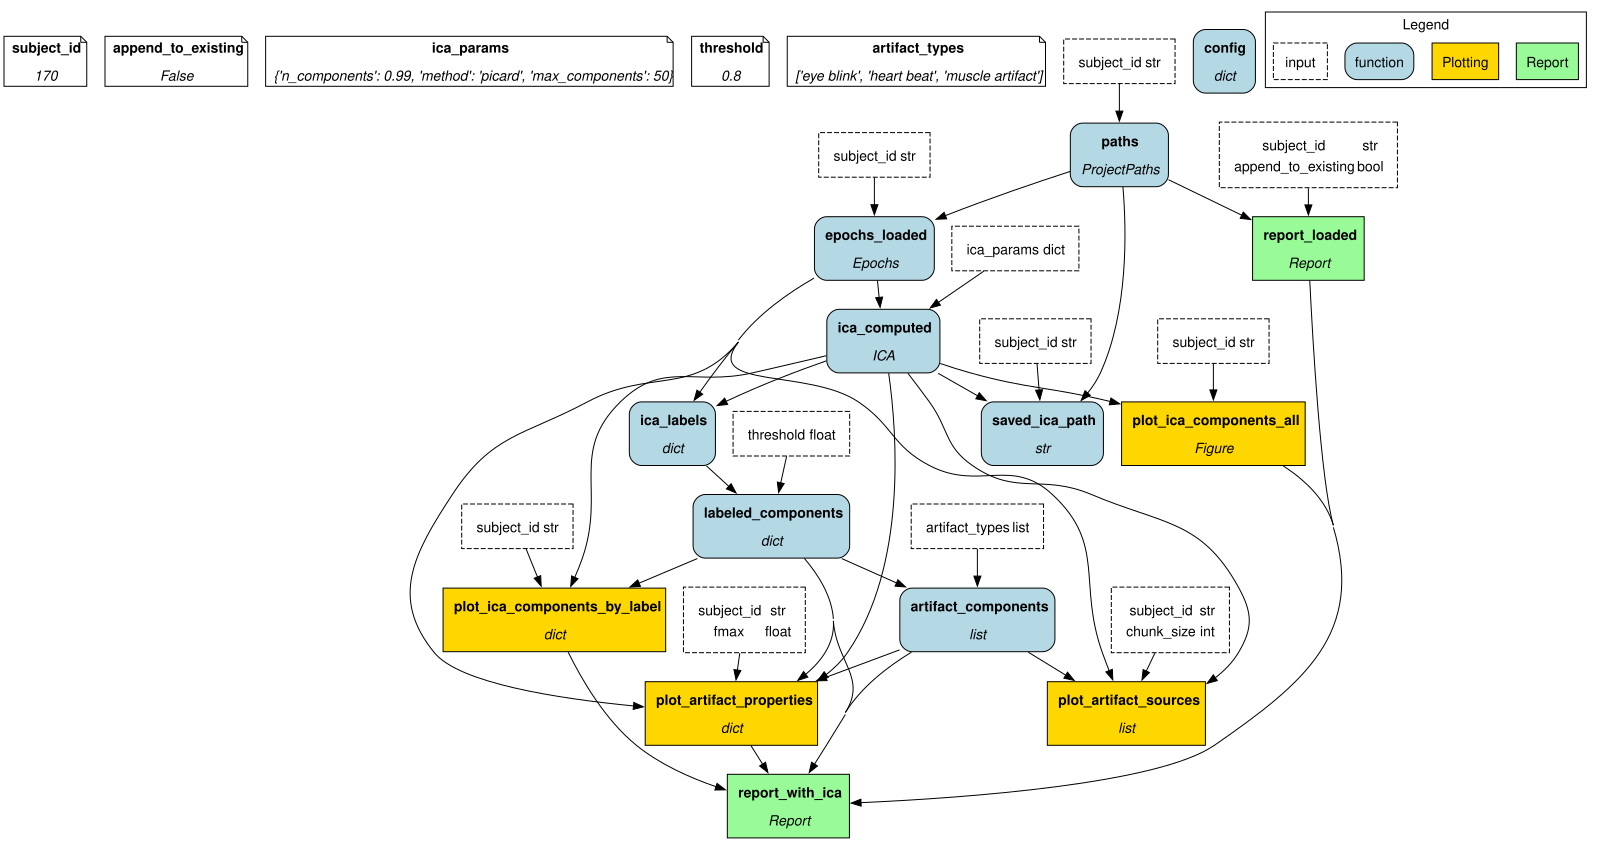

In [4]:
from hamilton import driver
from spectral.flows import ica_flow


dr_ica = driver.Driver(
    {  # config as first positional argument (no "config=")
        "subject_id": "170",
        "append_to_existing": False,
        "ica_params": {
            "n_components": 0.99,
            "method": "picard",
            "max_components": 50
        },
        "threshold": 0.8,
        "artifact_types": ["eye blink", "heart beat", "muscle artifact"]
    },
    ica_flow,  # modules as positional arguments
)
dr_ica.display_all_functions(orient="TB", custom_style_function=style_cfg)




In [ ]:
results_ica = dr_ica.execute(
    final_vars=[
        "saved_ica_path",
        "labeled_components",
        "artifact_components",
        "report_with_ica",
    ]
)

print("Artifact components:", results_ica["artifact_components"])

In [1]:
results_ica = dr_ica.execute(
    final_vars=[
        "saved_ica_path",
        "labeled_components",
        "artifact_components",
        "report_with_ica",
    ],
    inputs={
        "subject_id": "170",
        "append_to_existing": False,
        "ica_params": {"n_components": 0.99, "method": "picard", "max_components": 50},
        "threshold": 0.8,  # ICLabel probability threshold
        "artifact_types": ["eye blink", "heart beat", "muscle artifact"],
    },
)
print("Artifact components:", results["artifact_components"])


NameError: name 'dr_ica' is not defined